# Competition: Awake / N-REM / REM Classification

## Reading CSV files

In [1]:
import pandas as pd

training_mice  = pd.read_csv('./EEG_mouse_data_1.csv')
training_mice2 = pd.read_csv('./EEG_mouse_data_2.csv')

training_data = pd.concat([training_mice, training_mice2], ignore_index=True)

## Choosing features

In [2]:
feature_list = ["state"] + [f"amplitude_around_{i}_Hertz" for i in range(1, 26)]

input_training_mice = training_data[feature_list]
print(input_training_mice.head())

  state  amplitude_around_1_Hertz  amplitude_around_2_Hertz  \
0     n                  0.000009                  0.000014   
1     n                  0.000010                  0.000010   
2     n                  0.000011                  0.000077   
3     w                  0.000003                  0.000031   
4     w                  0.000010                  0.000011   

   amplitude_around_3_Hertz  amplitude_around_4_Hertz  \
0                  0.000013                  0.000014   
1                  0.000011                  0.000015   
2                  0.000034                  0.000019   
3                  0.000044                  0.000016   
4                  0.000012                  0.000017   

   amplitude_around_5_Hertz  amplitude_around_6_Hertz  \
0                  0.000023                  0.000009   
1                  0.000022                  0.000017   
2                  0.000013                  0.000006   
3                  0.000007                  0.000

## Normalize and encode data

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

scaler  = StandardScaler()
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

state = pd.DataFrame(input_training_mice['state'])
encoder.fit(state)

output_training_mice = encoder.transform(state)
input_training_mice  = input_training_mice.drop(columns=['state'])

for column in input_training_mice:
    column_data = input_training_mice[column].to_frame()
    scaler.fit(column_data)
    input_training_mice[column] = scaler.transform(column_data)

## Create model and fold

**Only change vs experiment 2:** Adam optimizer instead of SGD.

Adam adapts the learning rate individually for each parameter using the history of gradients,
which leads to faster and more stable convergence compared to SGD with a fixed learning rate.

In [4]:
import keras
from keras import layers
from sklearn.model_selection import KFold

keras.utils.set_random_seed(123)
kf = KFold(n_splits=3, shuffle=True)

def create_model():
    mlp = keras.Sequential([
        layers.Input(shape=(25,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(3, activation="softmax"),
    ])
    mlp.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Changed from SGD
        loss="categorical_crossentropy",
    )
    return mlp

mlp = create_model()
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235 (940.00 B)

 Trainable params: 235 (940.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [5]:
import numpy as np

history_list = []
trained_mlp  = []

for i, (train_index, test_index) in enumerate(kf.split(input_training_mice)):
    mlp = create_model()
    x_train, x_test = input_training_mice.iloc[train_index], input_training_mice.iloc[test_index]
    y_train, y_test = np.array(output_training_mice)[train_index], np.array(output_training_mice)[test_index]

    history = mlp.fit(
        x=x_train, y=y_train,
        validation_data=(x_test, y_test),
        epochs=50
    )

    history_list.append(history)
    trained_mlp.append(mlp)

Epoch 1/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5209 - val_loss: 0.4151
Epoch 2/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3852 - val_loss: 0.3782
Epoch 3/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3609 - val_loss: 0.3641
Epoch 4/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3501 - val_loss: 0.3566
Epoch 5/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3439 - val_loss: 0.3518
Epoch 6/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3397 - val_loss: 0.3484
Epoch 7/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3364 - val_loss: 0.3459
Epoch 8/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3338 - val_loss: 0.3440
Epoch 9/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3318 - val_loss: 0.3426
Epoch 10/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.3304 - val_loss: 0.3417
Epoch 11/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3293 - val_loss: 0.3411
Epoch 12/50
852/852 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

## Plot training history

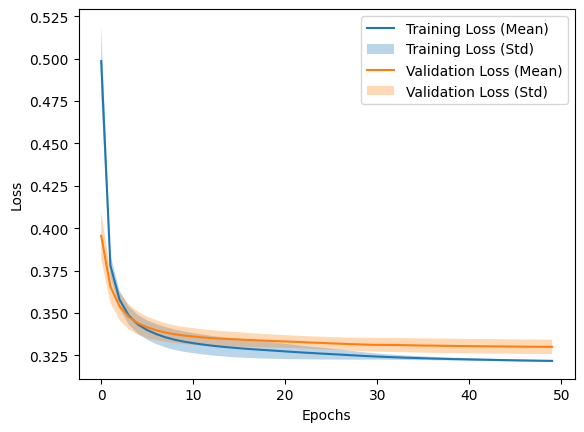

In [6]:
import matplotlib.pyplot as pl
%matplotlib inline

train_losses = np.array([history.history['loss']     for history in history_list])
val_losses   = np.array([history.history['val_loss'] for history in history_list])

mean_train_loss = np.mean(train_losses, axis=0)
std_train_loss  = np.std(train_losses,  axis=0)
mean_val_loss   = np.mean(val_losses,   axis=0)
std_val_loss    = np.std(val_losses,    axis=0)

pl.plot(mean_train_loss, label='Training Loss (Mean)')
pl.fill_between(range(len(mean_train_loss)), mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, alpha=0.3, label='Training Loss (Std)')

pl.plot(mean_val_loss, label='Validation Loss (Mean)')
pl.fill_between(range(len(mean_val_loss)), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, alpha=0.3, label='Validation Loss (Std)')

pl.xlabel('Epochs')
pl.ylabel('Loss')
pl.legend()
pl.show()

## Performance

426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


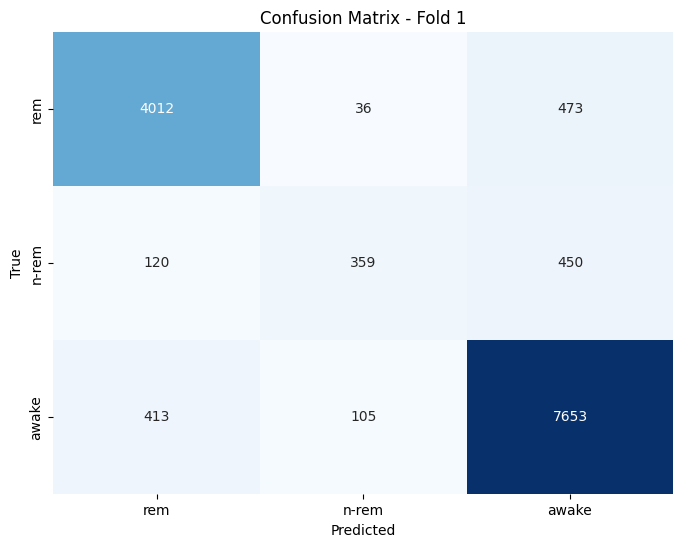

F1 per class - Fold 1: [0.88506508 0.50244927 0.91395474]
F1 macro     - Fold 1: 0.7671563605656916
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


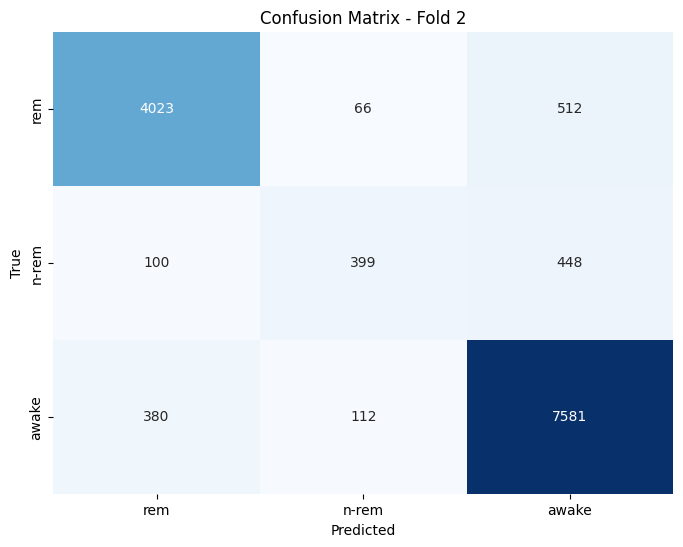

F1 per class - Fold 2: [0.88378735 0.52362205 0.91260383]
F1 macro     - Fold 2: 0.7733377405207739
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


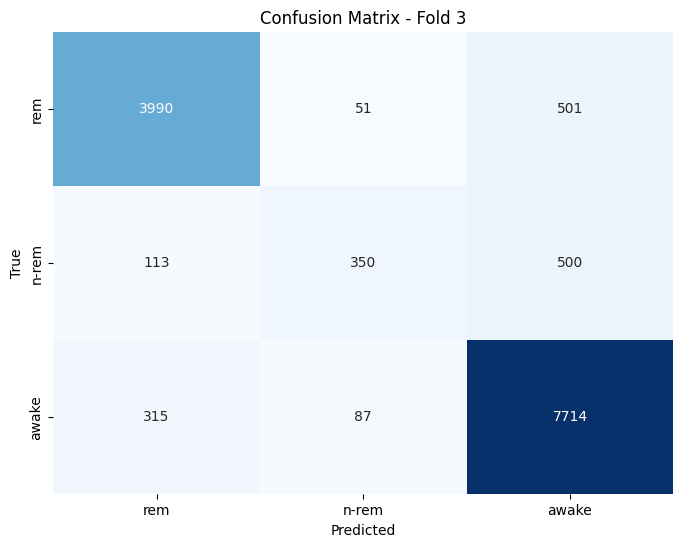

F1 per class - Fold 3: [0.890625   0.48242591 0.91664191]
F1 macro     - Fold 3: 0.7632309413077477


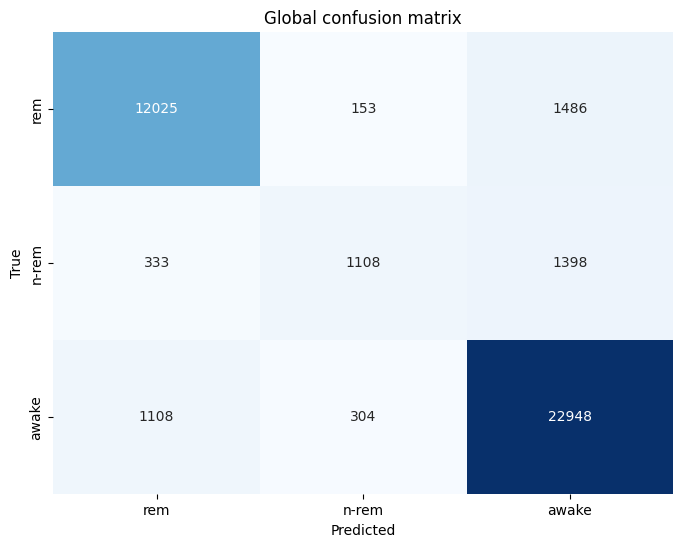

Mean F1 macro across all folds: 0.7679083474647377


In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns

def plot_confusion_matrix(confusion_matrix, title):
    pl.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix.astype(int), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["rem", "n-rem", "awake"], yticklabels=["rem", "n-rem", "awake"])
    pl.title(title)
    pl.xlabel('Predicted')
    pl.ylabel('True')
    pl.show()

mean_confusion_matrix = np.zeros((3, 3))
f1_scores_macro = []  # macro F1 as required by the competition

for i, (train_index, test_index) in enumerate(kf.split(input_training_mice)):
    predictions = trained_mlp[i].predict(input_training_mice.iloc[test_index])
    true_labels = np.array(output_training_mice)[test_index]

    max_predictions = [np.argmax(p) for p in predictions]
    max_true_labels = [np.argmax(t) for t in true_labels]

    cm = confusion_matrix(max_true_labels, max_predictions)
    mean_confusion_matrix += cm
    plot_confusion_matrix(cm, f'Confusion Matrix - Fold {i + 1}')

    f1_per_class = f1_score(max_true_labels, max_predictions, average=None)
    f1_macro     = f1_score(max_true_labels, max_predictions, average='macro')
    f1_scores_macro.append(f1_macro)

    print(f"F1 per class - Fold {i+1}: {f1_per_class}")
    print(f"F1 macro     - Fold {i+1}: {f1_macro}")

plot_confusion_matrix(mean_confusion_matrix, 'Global confusion matrix')

print(f"Mean F1 macro across all folds: {np.mean(f1_scores_macro)}")

## Predict on test data

Preprocessing is identical to training data (same scaler, same features).

In [13]:
# Load test data
test_data = pd.read_csv('./EEG_mouse_data_test.csv')

# Même preprocessing que les données d'entraînement
test_features = test_data[[f"amplitude_around_{i}_Hertz" for i in range(1, 26)]].copy()

for column in test_features:
    column_data = test_features[column].to_frame()
    scaler.fit(column_data)
    test_features[column] = scaler.transform(column_data)

# Prédictions dans l'ordre du test set (pas de tri, pas de shuffle)
predictions  = trained_mlp[-1].predict(test_features)
pred_indices = [np.argmax(p) for p in predictions]

# Noms texte au lieu d'entiers
class_names = encoder.categories_[0]  # ['awake', 'n-rem', 'rem'] ou similaire
pred_labels = np.array([class_names[i] for i in pred_indices])

# Sauvegarder
np.save('./test_pred.npy', pred_labels)
print(f"Saved {len(pred_labels)} predictions")
print(np.unique(pred_labels, return_counts=True))

# Vérification : doit afficher les noms, pas des chiffres
print("Exemple:", pred_labels[:5])

2504/2504 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Saved 80109 predictions
(array(['n', 'r', 'w'], dtype='<U1'), array([27074,  2487, 50548]))
Exemple: ['n' 'n' 'w' 'n' 'n']
